In [1]:
import json
from pathlib import Path
import os
import numpy as np
import torch
from matplotlib import pyplot as plt

from robomimic.utils import file_utils as FileUtils
from robomimic.utils import obs_utils as ObsUtils

from world_model_utils import (
    build_state_from_obs_dict,
    load_init_state_json,
    load_model_for_eval,
    plot_rzz_world_model_branches,
    rollout_policy_for_rzz_analysis,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

/home/zoellner/.conda/envs/guided_diffusion/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Finding the right env seed to test the diffusion guidance
could use env_seeds.sub to roll out from more starting positions and find the ones where policy is diverse and model is accurate

In [2]:
# Prepare policy, environment, and learned world model
CKPT_SOURCE = "gilbreth"  # "local" or "gilbreth"
CKPT_PATH = (
    "/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth"
    if CKPT_SOURCE == "gilbreth"
    else "../models/can/model_epoch_2000.pth"
)

ckpt = torch.load(CKPT_PATH, map_location="cpu")
cfg = json.loads(ckpt["config"])
ObsUtils.initialize_obs_utils_with_obs_specs(cfg["observation"]["modalities"])

env, _ = FileUtils.env_from_checkpoint(
    ckpt_path=CKPT_PATH,
    render=True,
    render_offscreen=True,
)
policy, _ = FileUtils.policy_from_checkpoint(
    ckpt_path=CKPT_PATH,
    device=device,
    verbose=True,
)

predictor_learned, stats, _, eval_meta = load_model_for_eval(
    model_or_run_path="../models/dynamics/baseline_mlp",
    predictor_kind="learned",
    device=device,
    load_val_trajectories=False,
)

print(f"Policy ckpt: {CKPT_PATH}")
print(f"World-model run dir: {eval_meta['run_dir']}")


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/zoellner/src/guided-diffusion/robosuite/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)


Created environment with name PickPlaceCan
Action size is 7
============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "can_mh_lowdim",
        "validate": false,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "guided_diffusion"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 50,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
        "epoch_every_n_steps": 100,
        "validation_epoch_every_n_steps": 10,
        "env": null,
        "additional_envs": null,
        "render": false,
        "render_video": true,
        "keep_all_videos": true,
        "video_skip": 2,
        "rollout": {
            "enabled": true,
     

In [3]:
potential_seed_run_dirs = [
    Path("../outputs/can_rollouts/snr/n16h300r60g1bYfYv1"),
    Path("../outputs/can_rollouts/snr/n16h300r60g1bYfYv4"),
]

n16h300r60g1bYfYv1 rep1: steps=165  return=1.0000 success=True
n16h300r60g1bYfYv1 rep2: steps=187  return=1.0000 success=True
n16h300r60g1bYfYv1 rep3: steps=120  return=1.0000 success=True


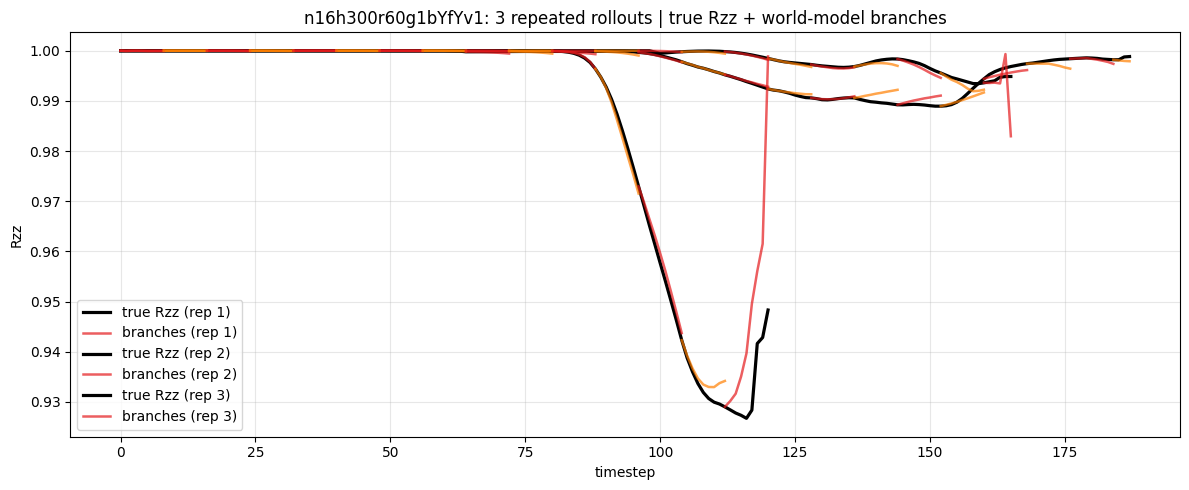

n16h300r60g1bYfYv4 rep1: steps=167  return=1.0000 success=True
n16h300r60g1bYfYv4 rep2: steps=167  return=1.0000 success=True
n16h300r60g1bYfYv4 rep3: steps=200  return=1.0000 success=True


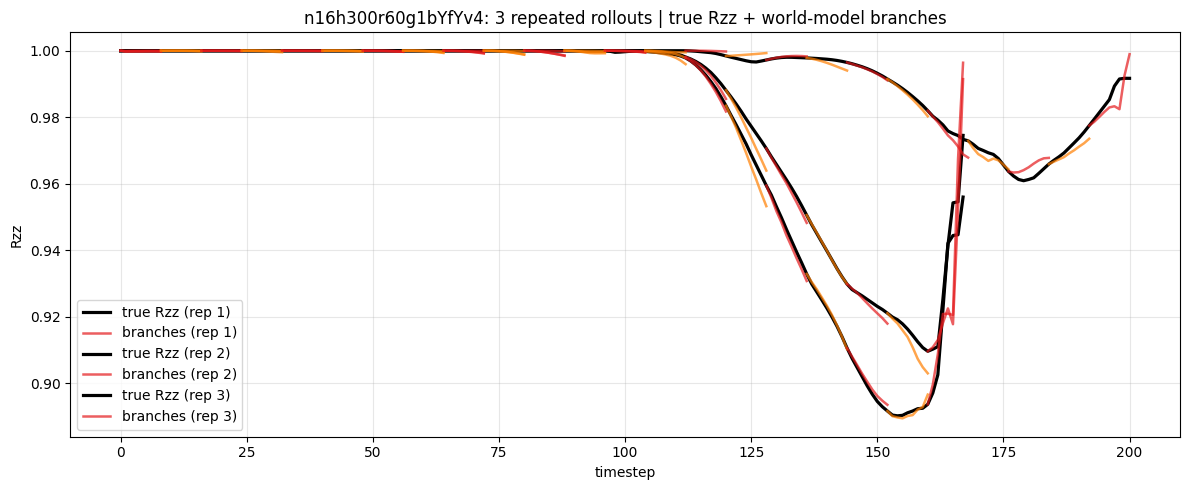

Finished 2 seed groups, 3 rollouts each.


In [6]:
# Rollout each potential seed init-state 3 times and overlay world-model branch predictions per seed

horizon = 300
branch_horizon = 8
branch_stride = 8
video_skip = 1
camera_name = "frontview"
n_repeats_per_seed = 3

analysis_dir = Path("../outputs/can_rollouts/diffusion_guidance_checks")
analysis_dir.mkdir(parents=True, exist_ok=True)

seed_rollouts = {}
for run_dir in potential_seed_run_dirs:
    init_state_path = run_dir / "init_state.json"
    if not init_state_path.exists():
        print(f"Skipping {run_dir}: no init_state.json")
        continue

    init_state = load_init_state_json(str(init_state_path))
    seed_rollouts[run_dir.name] = []

    fig, ax = plt.subplots(figsize=(12, 5))
    for rep in range(n_repeats_per_seed):
        video_path = analysis_dir / f"{run_dir.name}_rep{rep+1}_h{horizon}_{camera_name}.mp4"

        rollout_result = rollout_policy_for_rzz_analysis(
            env=env,
            policy=policy,
            build_state_from_obs_fn=build_state_from_obs_dict,
            horizon=horizon,
            video_path=str(video_path),
            video_skip=video_skip,
            camera_name=camera_name,
            mujoco_body_name="Can_main",
            init_state=init_state,
        )

        seed_rollouts[run_dir.name].append(rollout_result)
        print(
            f"{run_dir.name} rep{rep+1}: steps={rollout_result['steps_executed']} ",
            f"return={rollout_result['total_reward']:.4f} success={rollout_result['success']}"
        )

        plot_rzz_world_model_branches(
            states=rollout_result["states"],
            actions=rollout_result["actions"],
            predictor=predictor_learned,
            stats=stats,
            device=device,
            branch_horizon=branch_horizon,
            branch_stride=branch_stride,
            title=f"{run_dir.name}: 3 repeated rollouts | true Rzz + world-model branches",
            ax=ax,
            show=False,
            true_label=f"true Rzz (rep {rep+1})",
            branch_label=f"branches (rep {rep+1})",
            branch_alpha=0.7,
            show_legend=True,
        )

    plt.show()

print(f"Finished {len(seed_rollouts)} seed groups, {n_repeats_per_seed} rollouts each.")

### Rollout with Diffusion guidance ?

test
